In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)
import json
from matplotlib.ticker import MaxNLocator, LogLocator

from scipy.fftpack import fft

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)

idmrg_file = '../../data/iDMRG/scanChi1000/corrs/results.h5'
df_i = read_corrs(idmrg_file)

In [6]:
ccdir = '../../data/iDMRG/Vpm3.8cc/'
ccfiles = os.listdir(ccdir)
s_list = []
xi_list = []
for file in ccfiles : 
    if file.endswith('.h5'):
        psi, _ = io.load_mps_with_metadata(os.path.join(ccdir, file))
        s_list.append(psi.entanglement_entropy()[0])
        xi_list.append(psi.correlation_length2())


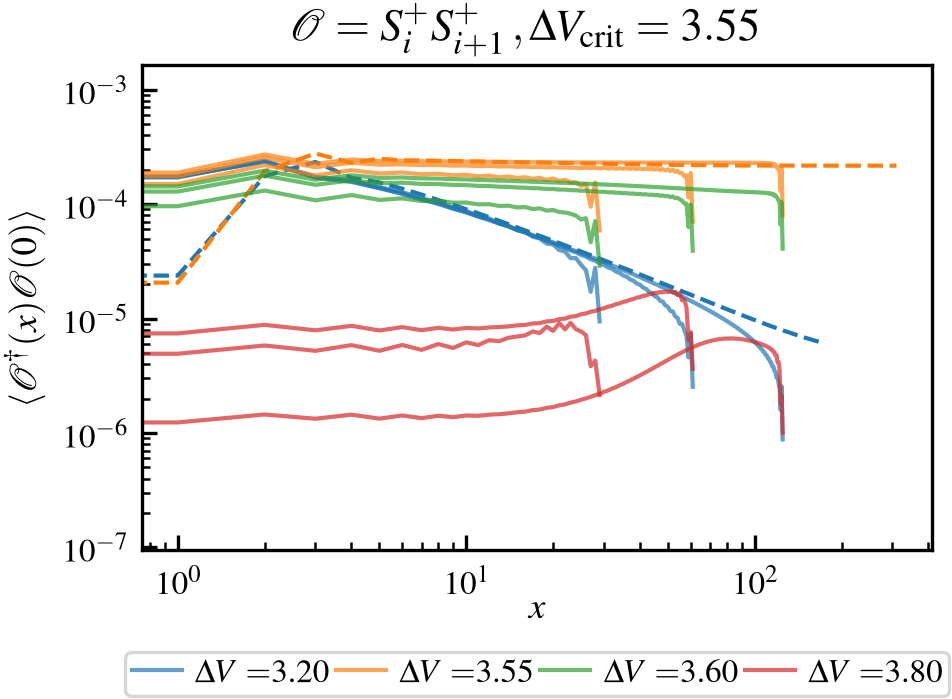

In [ ]:
fig, ax = plt.subplots(1)
dVvals = [ 3.2, 3.55,  3.6, 3.8, ]

for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    ax.plot(np.abs(seldf_i["spin2_corr"].values[0]), c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V = $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        ax.plot(np.abs(seldf["spin2vec"].values[0]), c=col, alpha=0.7, label=label)
        
ax.set_ylabel(r'$\langle \mathcal{O}^\dagger(x)\mathcal{O}(0)\rangle$')
ax.set_xlabel(r'$x$', labelpad=-2)
ax.set_xscale('log')
ax.set_yscale('log')

fig.suptitle(r"$ \mathcal{O} = S^+_iS^+_{i+1}\, , \Delta V_{\mathrm{crit}} = 3.55$")

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels, ncol=len(dVvals), columnspacing=0.2, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(0.5, -0.3), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax.transAxes)

# fig.savefig("figures/Additional_LRO.pdf", bbox_inches='tight')

/tmp/ipykernel_92760/795499933.py:21: RuntimeWarning: divide by zero encountered in power
  ax[0,0].plot(xvals[1:], (Kc/np.pi**2) * ((xvals)**-2.0)[1:], label=r'$\frac{K_c}{\pi^2 x^2}$', lw=0.7, c=colbos)
/tmp/ipykernel_92760/795499933.py:29: RuntimeWarning: divide by zero encountered in power
  ax[0,1].plot(xvals[1:], (0.25*Ks/np.pi**2) * (xvals**-2.0)[1:], label=r'$\frac{K_s}{4\pi^2x^2}$', lw=0.7, c=colbos)


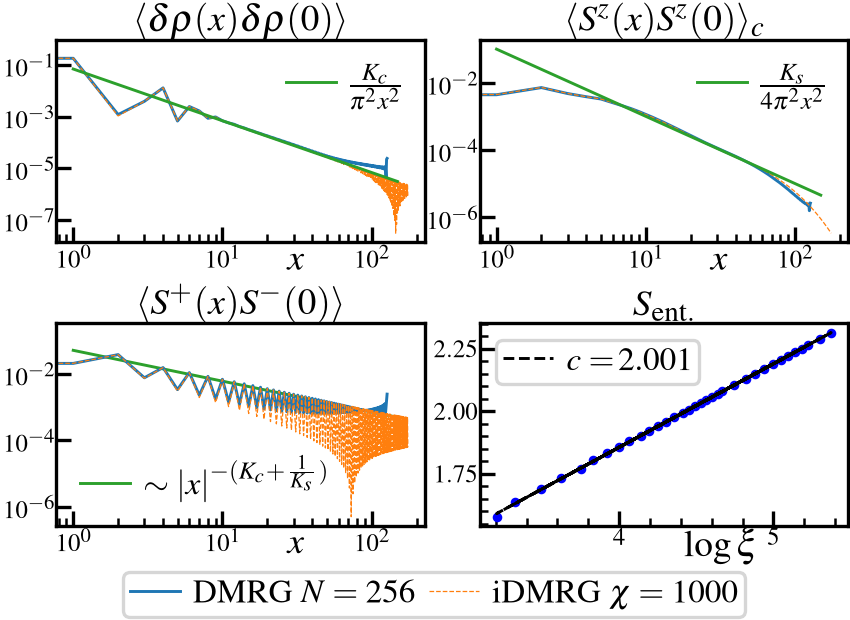

In [ ]:
fig, ax = plt.subplots(2,2, )
fig_dims = ssh.set_size(fraction=1.0, subplots=(2,2))
fig.set_size_inches(fig_dims)
fig.subplots_adjust(hspace=0.4, wspace=0.15)
colfd, colid, colbos = 'C0', 'C1', 'C2'

seldf = julio.select_N_dv_from_df(256, 3.2, df)
seldf_i = select_dV(df_i, 3.2, atol=1e-7)
Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)

chargeconn = np.abs(seldf["chargeconn"].values[0])
chargeconn_i = seldf_i["charge_corr"].values[0]
spinzconn = np.abs(seldf["szconn"].values[0])
spinzconn_i = seldf_i["spinz_corr"].values[0]
spmconn = np.abs(seldf["spmconn"].values[0])
spmconn_i = np.abs(seldf_i["spsm_corr"].values[0])

xvals = np.arange(150)
ax[0,0].loglog(chargeconn, lw=0.7, c=colfd)
ax[0,0].loglog(chargeconn_i, ls='--',lw=0.3, c=colid)
ax[0,0].plot(xvals[1:], (Kc/np.pi**2) * ((xvals)**-2.0)[1:], label=r'$\frac{K_c}{\pi^2 x^2}$', lw=0.7, c=colbos)
ax[0,0].set_xlabel(r'$x$',labelpad=-4)
ax[0,0].set_title(r'$\langle\delta\rho(x)\delta\rho(0)\rangle$', pad=-1)
ax[0,0].xaxis.set_label_coords(0.65, -0.01)
ax[0,0].legend()

ax[0,1].loglog(spinzconn,lw=0.7, c=colfd)
ax[0,1].loglog(spinzconn_i, ls='--',lw=0.3, c=colid)
ax[0,1].plot(xvals[1:], (0.25*Ks/np.pi**2) * (xvals**-2.0)[1:], label=r'$\frac{K_s}{4\pi^2x^2}$', lw=0.7, c=colbos)
ax[0,1].set_xlabel(r'$x$',labelpad=-4)
ax[0,1].set_title(r'$\langle S^z(x) S^z(0)\rangle_c$', pad=-1)
ax[0,1].xaxis.set_label_coords(0.65, -0.01)
ax[0,1].legend()

scale_spm = 0.065
scale_spm = 1/(2*np.pi**2)
ax[1,0].plot(xvals[1:], scale_spm * (xvals[1:])**(-(Kc+1/Ks)), label=r'$\sim |x|^{-(K_c + \frac{1}{K_s})}$', lw=0.7, c=colbos)
ax[1,0].legend()
ax[1,0].loglog(spmconn,lw=0.7, c=colfd, label=r'DMRG $N=256$')
ax[1,0].loglog(spmconn_i, ls='--',lw=0.3, c=colid, label=r'iDMRG $\chi=1000$')
ax[1,0].set_xlabel(r'$x$',labelpad=-4)
ax[1,0].set_title(r'$\langle S^+(x) S^-(0)\rangle$', pad=-1)
ax[1,0].xaxis.set_label_coords(0.65, -0.01)


ax[1,1].plot(np.log(xi_list), s_list, ls='', marker='.', c='b')
m, ic = np.polyfit(np.log(xi_list), np.array(s_list),1 )
cc = m * 6
ax[1,1].plot(np.log(xi_list), m * np.log(xi_list) + ic, c='k', ls='--', label=r'$c=\,$'+f'{cc:0.3f}', lw=0.7)
ax[1,1].legend(frameon=True, fancybox=True)
ax[1,1].set_xlabel(r'$\log\xi$')
ax[1,1].set_title(r'$S_{\mathrm{ent.}}$', pad=-1)
ax[1,1].xaxis.set_label_coords(0.65, -0.01)

handles, labels = ax[1,0].get_legend_handles_labels()
handles, labels = handles[1:], labels[1:]
lgd = fig.legend(handles, labels, ncol=2, columnspacing=0.4, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(1.025, -0.45), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax[1,0].transAxes)

for axval in ax.reshape(4):
    axval.tick_params(which='both',labelsize=6, pad=0.5)

# fig.savefig('figures/dV3_2isLL.pdf', bbox_inches='tight')

/tmp/ipykernel_15503/2369795706.py:22: RuntimeWarning: divide by zero encountered in power
  ax[0].plot(xvals[1:], (Kc/np.pi**2) * ((xvals)**-2.0)[1:], label=r'$\frac{K_c}{\pi^2 x^2}$', lw=0.7, c=colbos)
/tmp/ipykernel_15503/2369795706.py:34: RuntimeWarning: divide by zero encountered in power
  ax[1].plot(xvals[1:], (0.25*Ks/np.pi**2) * (xvals**-2.0)[1:], label=r'$\frac{K_s}{4\pi^2x^2}$', lw=0.7, c=colbos)


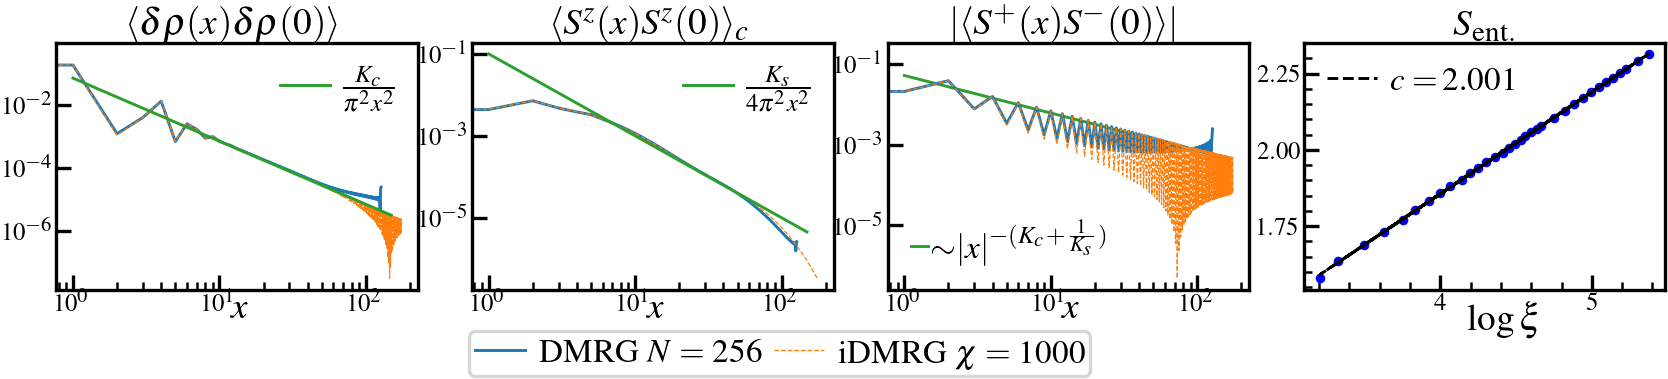

In [ ]:
fig, ax = plt.subplots(1,4)
# fig_dims = ssh.set_size(width_pt=246*2, fraction=1.0, subplots=(1,4))
fig_dims = ssh.set_size_ht(width_pt=500, fraction=1.0, subplots=(1,4))
fig.set_size_inches(fig_dims)
fig.subplots_adjust(hspace=0.4, wspace=0.15)
colfd, colid, colbos = 'C0', 'C1', 'C2'

seldf = julio.select_N_dv_from_df(256, 3.2, df)
seldf_i = select_dV(df_i, 3.2, atol=1e-7)
Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)

chargeconn = np.abs(seldf["chargeconn"].values[0])
chargeconn_i = seldf_i["charge_corr"].values[0]
spinzconn = np.abs(seldf["szconn"].values[0])
spinzconn_i = seldf_i["spinz_corr"].values[0]
spmconn = np.abs(seldf["spmconn"].values[0])
spmconn_i = np.abs(seldf_i["spsm_corr"].values[0])

xvals = np.arange(150)
ax[0].loglog(chargeconn, lw=0.7, c=colfd)
ax[0].loglog(chargeconn_i, ls='--',lw=0.3, c=colid)
ax[0].plot(xvals[1:], (Kc/np.pi**2) * ((xvals)**-2.0)[1:], label=r'$\frac{K_c}{\pi^2 x^2}$', lw=0.7, c=colbos)
ax[0].set_xlabel(r'$x$',labelpad=-4)
ax[0].set_title(r'$\langle\delta\rho(x)\delta\rho(0)\rangle$', pad=-1)
ax[0].xaxis.set_label_coords(0.50, -0.01)
# ymin, ymax = ax[0].get_ylim()
# lo = int(np.floor(np.log10(ymin)))
# hi = int(np.ceil(np.log10(ymax)))
# ax[0].yaxis.set_major_locator(LogLocator(base=10, numticks=min(3, hi - lo + 1)))
ax[0].legend()

ax[1].loglog(spinzconn,lw=0.7, c=colfd)
ax[1].loglog(spinzconn_i, ls='--',lw=0.3, c=colid)
ax[1].plot(xvals[1:], (0.25*Ks/np.pi**2) * (xvals**-2.0)[1:], label=r'$\frac{K_s}{4\pi^2x^2}$', lw=0.7, c=colbos)
ax[1].set_xlabel(r'$x$',labelpad=-4)
ax[1].set_title(r'$\langle S^z(x) S^z(0)\rangle_c$', pad=-1)
ax[1].xaxis.set_label_coords(0.50, -0.01)
ax[1].legend()

scale_spm = 0.065
scale_spm = 1/(2*np.pi**2)
ax[2].plot(xvals[1:], scale_spm * (xvals[1:])**(-(Kc+1/Ks)), label=r'$\sim\!\!|x|^{-(K_c + \frac{1}{K_s})}$', lw=0.7, c=colbos)
# ax[2].legend(handlelength=0.5, handletextpad=0.1)
ax[2].legend()
ax[2].loglog(spmconn,lw=0.7, c=colfd, label=r'DMRG $N=256$')
ax[2].loglog(spmconn_i, ls='--',lw=0.3, c=colid, label=r'iDMRG $\chi=1000$')
ax[2].set_xlabel(r'$x$',labelpad=-4)
ax[2].set_title(r'$|\langle S^+(x) S^-(0)\rangle|$', pad=-1)
ax[2].xaxis.set_label_coords(0.50, -0.01)


ax[3].plot(np.log(xi_list), s_list, ls='', marker='.', c='b')
m, ic = np.polyfit(np.log(xi_list), np.array(s_list),1 )
cc = m * 6
ax[3].plot(np.log(xi_list), m * np.log(xi_list) + ic, c='k', ls='--', label=r'$c=\,$'+f'{cc:0.3f}', lw=0.7)
ax[3].legend()
ax[3].set_xlabel(r'$\log\xi$')
ax[3].set_title(r'$S_{\mathrm{ent.}}$', pad=-1)
ax[3].xaxis.set_label_coords(0.55, -0.05)

handles, labels = ax[2].get_legend_handles_labels()
handles, labels = handles[1:], labels[1:]
lgd = fig.legend(handles, labels, ncol=2, columnspacing=0.4, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(-0.3, -0.35), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax[2].transAxes)

for axval in ax:
    axval.tick_params(axis='x',which='both',labelsize=6, pad=0.7)
    axval.tick_params(axis='y',which='both',labelsize=6, pad=0.5)

fig.savefig('figures/dV3_2isLL_widetext.pdf', bbox_inches='tight')